In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir, evaluations_dir
from embedding_utils import perform_pca_on_embeddings
from annotation_utils import load_marcotte_subtypes
from training_configuration import PATHWAYS_3

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

from common import evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

subtypes_marcotte = load_marcotte_subtypes(embedding_df.cell_line.unique())

pca_embeddings_dict = {}
for model in PATHWAYS_3:
    print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model], n_components=6)


for model in PATHWAYS_3:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

EGFR_MAPK__logobs
Explained variance for cytof_init BT20: [0.44624721 0.22999238 0.15480555 0.07631069 0.05231995 0.02963636]; Total: 0.9893
Explained variance for cytof_init EVSAT: [0.36258046 0.2586136  0.14572356 0.12222268 0.06901397 0.03341275]; Total: 0.9916
Explained variance for cytof_init HCC1500: [0.3855114  0.23499979 0.14321328 0.11710235 0.06771222 0.03618976]; Total: 0.9847
Explained variance for cytof_init HCC2185: [0.43132387 0.20287879 0.15685366 0.10065744 0.05489651 0.03985373]; Total: 0.9865
Explained variance for cytof_init MCF7: [0.40257985 0.348461   0.11099631 0.06419869 0.05163968 0.02023075]; Total: 0.9981
Explained variance for cytof_init UACC3199: [0.44968465 0.22886735 0.14467663 0.06495716 0.05207483 0.04387658]; Total: 0.9841
Explained variance for cytof_init UACC893: [0.49689166 0.19530375 0.12593744 0.09125765 0.04335653 0.02419214]; Total: 0.9769
Explained variance for cytof_init_plus_intr BT20: [0.51042773 0.21917628 0.14210671 0.04605171 0.04029568 0

In [66]:
pca_embedding_df = pd.concat(
    [
        pca_embeddings_dict[model].assign(model=model)
        for model in PATHWAYS_3
    ]
)

# Embeddings annotated by Luminal/Basal

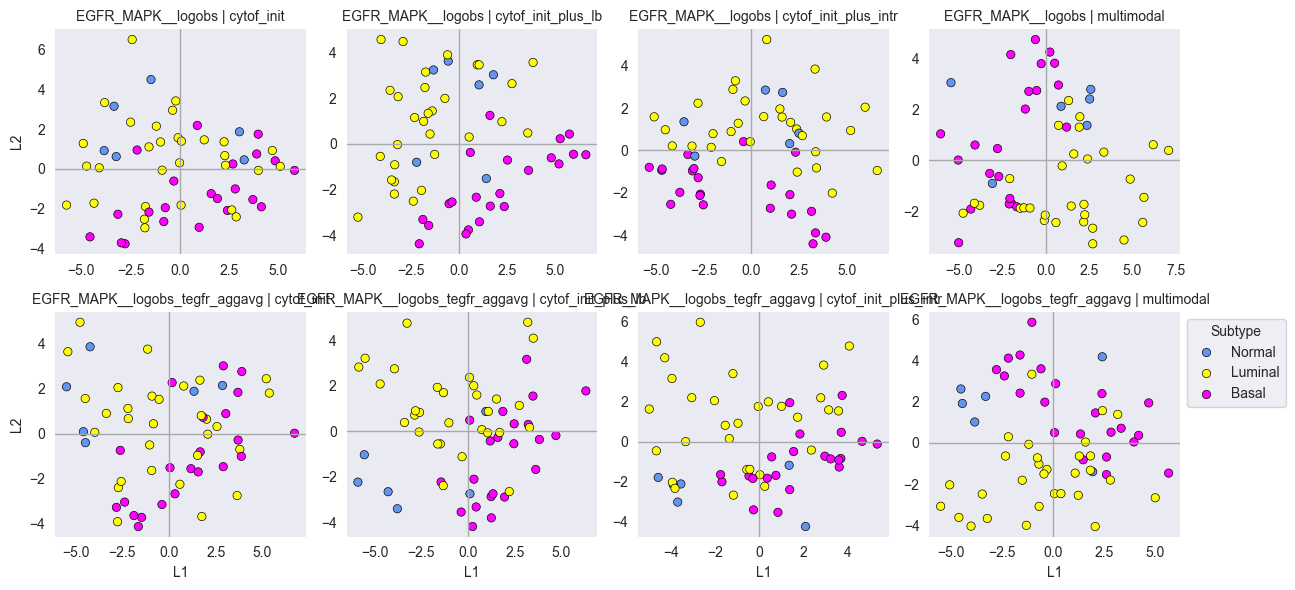

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="Subtype", bbox_to_anchor=(1, 1))
plt.show()

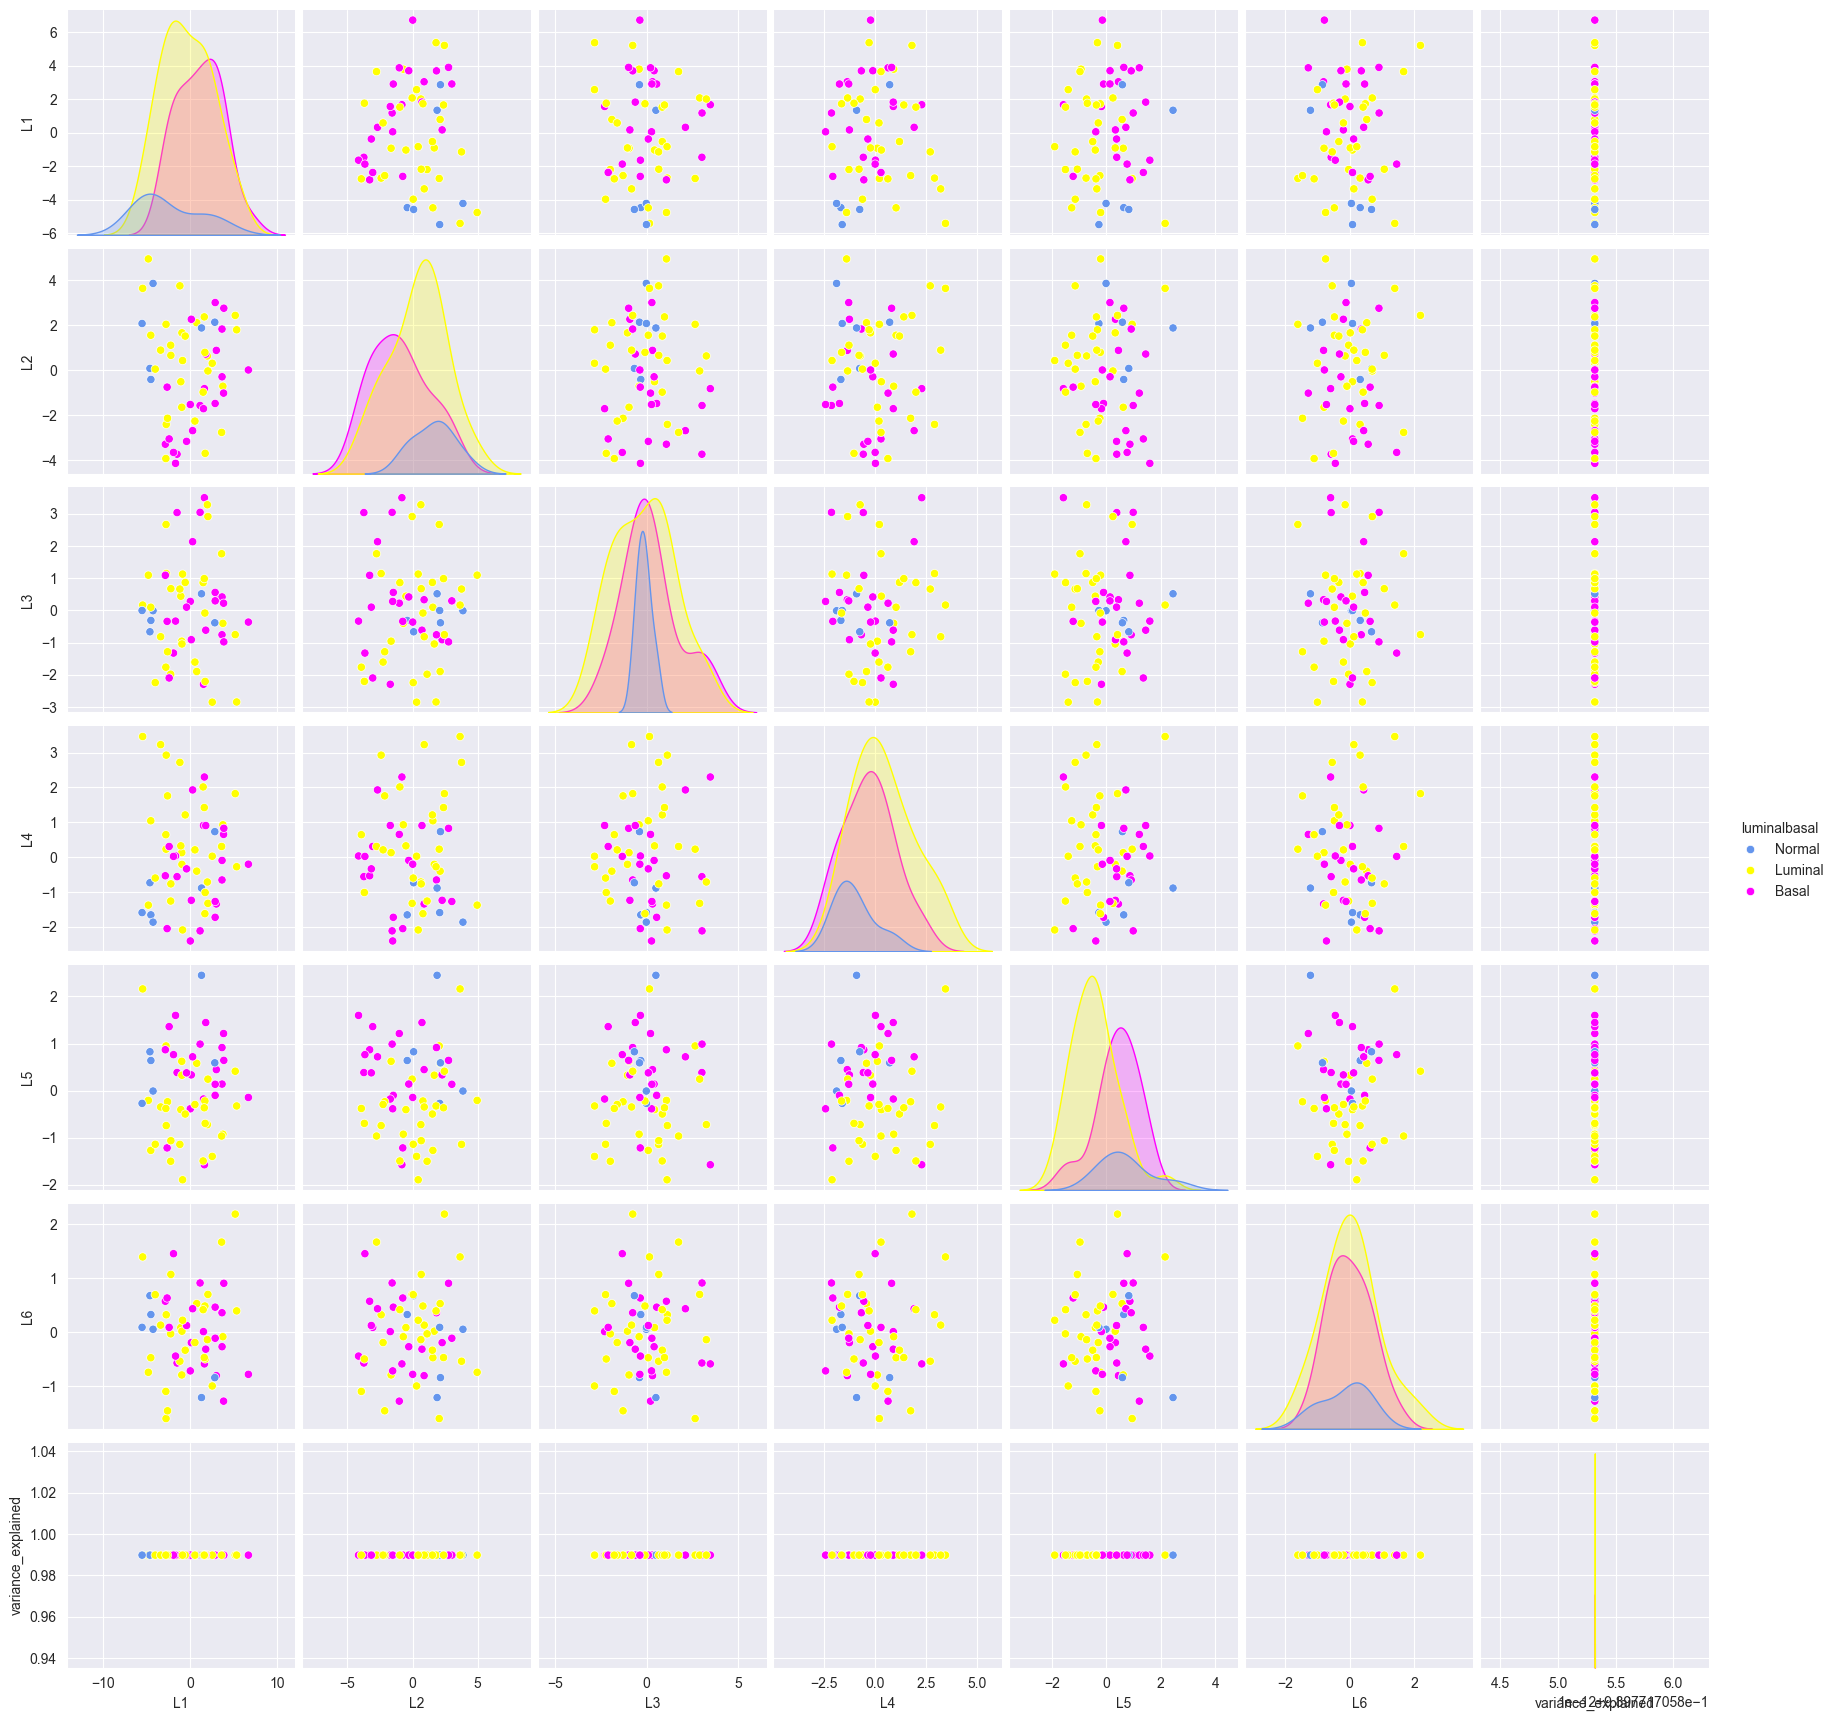

In [68]:
sns.pairplot(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
        & (pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg")
        & (pca_embedding_df.context == "cytof_init")
    ],
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
)

# Check association with EGFR transcript levels

In [69]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)
pp38 = cytof_init["p.p38"]
pp38 -= pp38.mean()
pp90rsk = cytof_init["p.p90RSK"]
pp90rsk -= pp90rsk.mean()
pmek = cytof_init["p.MEK"]
pmek -= pmek.mean()
del cytof_init

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
tpls3 = transcriptomics["PLS3"]
tpls3 -= tpls3.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= proteomics.mean()
pisoc1 = proteomics["ISOC1"]
pisoc1 -= pisoc1.mean()
del proteomics

In [70]:
pca_embedding_df["p.p38"] = pp38.loc[pca_embedding_df.index]
pca_embedding_df["p.p90RSK"] = pp90rsk.loc[pca_embedding_df.index]
pca_embedding_df["p.MEK"] = pmek.loc[pca_embedding_df.index]
pca_embedding_df["tEGFR"] = tegfr.loc[pca_embedding_df.index]
pca_embedding_df["pISOC1"] = pisoc1.loc[pca_embedding_df.index]
pca_embedding_df["tPLS3"] = tpls3.loc[pca_embedding_df.index]

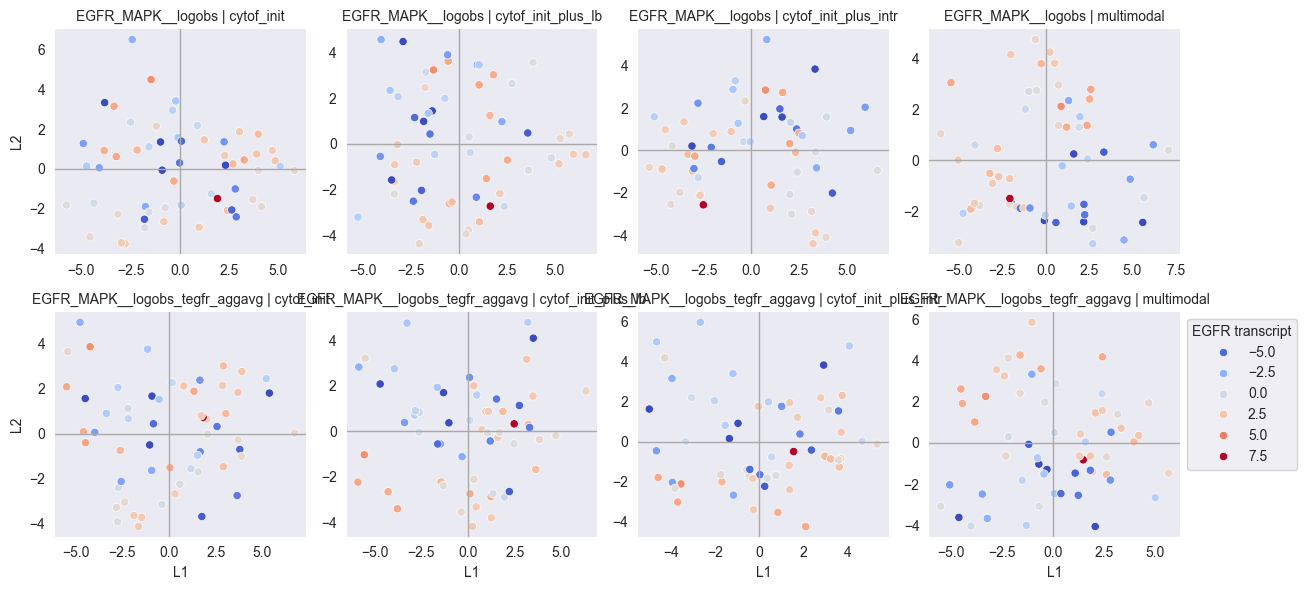

In [75]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="tEGFR",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR transcript", bbox_to_anchor=(1, 1))

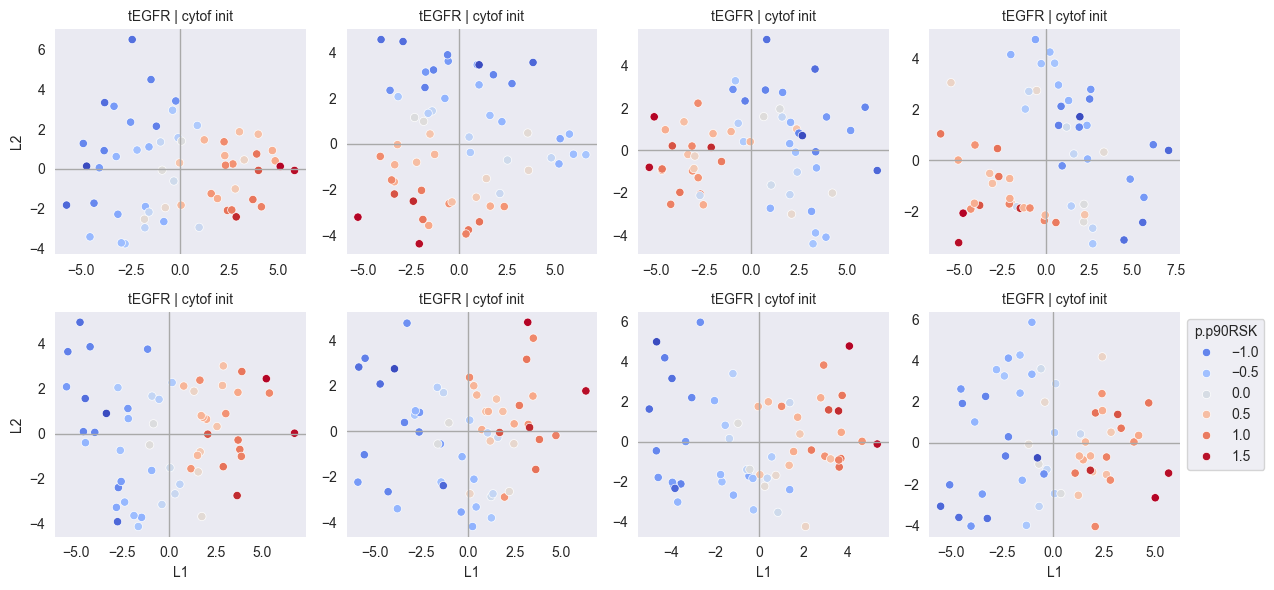

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Then override the mapping dictionaries for clarity
g.set_titles(
    row_template="tEGFR",
    col_template="cytof init"
)

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="p.p90RSK", bbox_to_anchor=(1, 1))

# plt.savefig("tEGFR_BT20_cytof_init_embeddings_p90RSK.svg")
plt.show()

Specifically check relationship of tEGFR model, cytof_init_plus_lb context with tEGFR levels

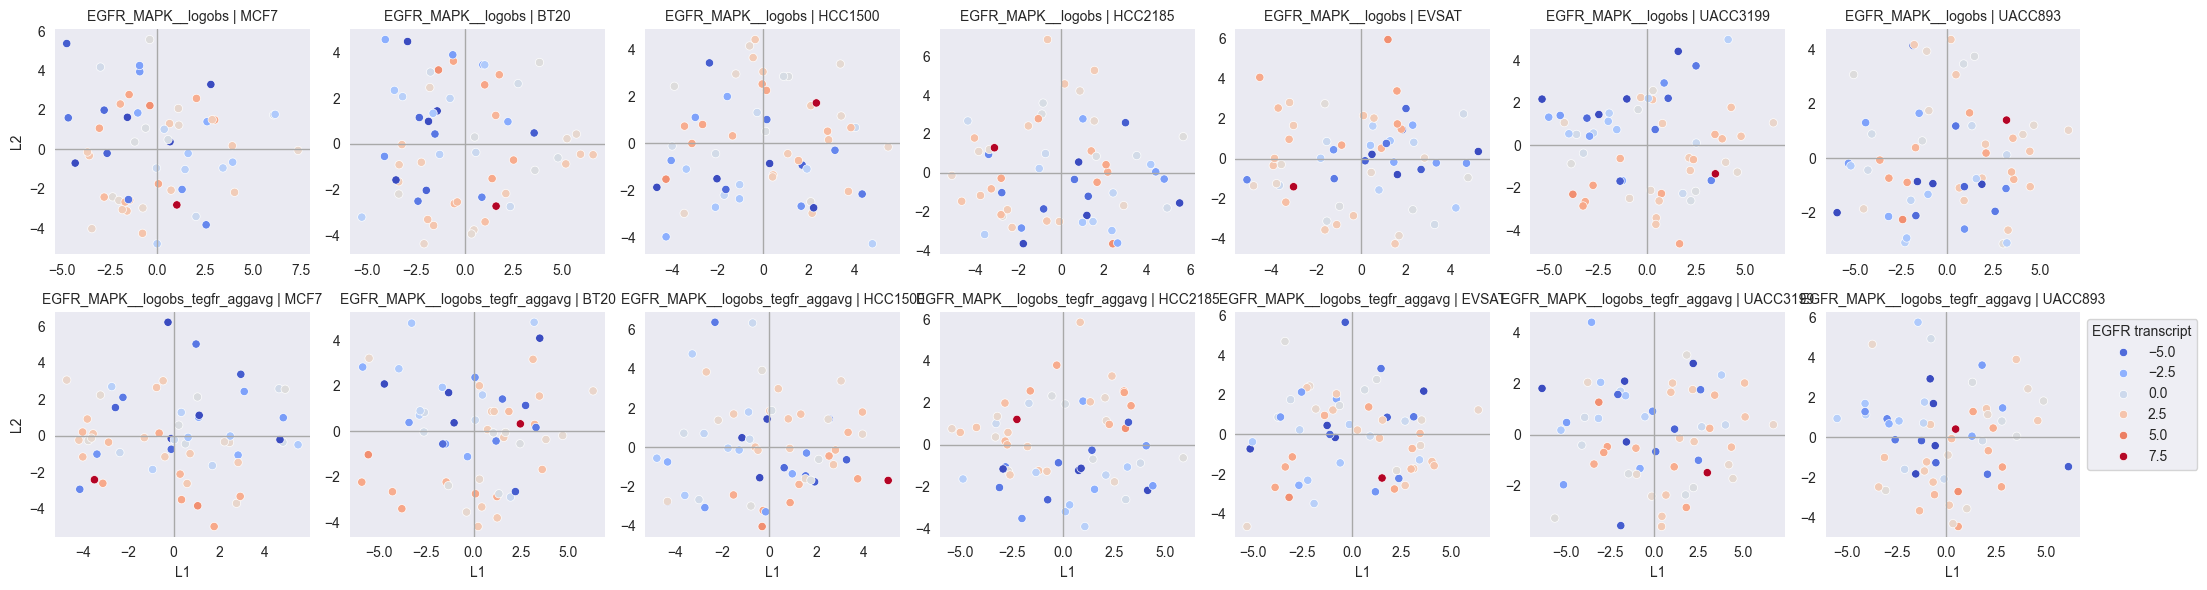

In [84]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.context == "cytof_init_plus_lb")],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "HCC2185", "EVSAT", "UACC3199", "UACC893"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="tEGFR",
    palette="coolwarm",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR transcript", bbox_to_anchor=(1, 1))

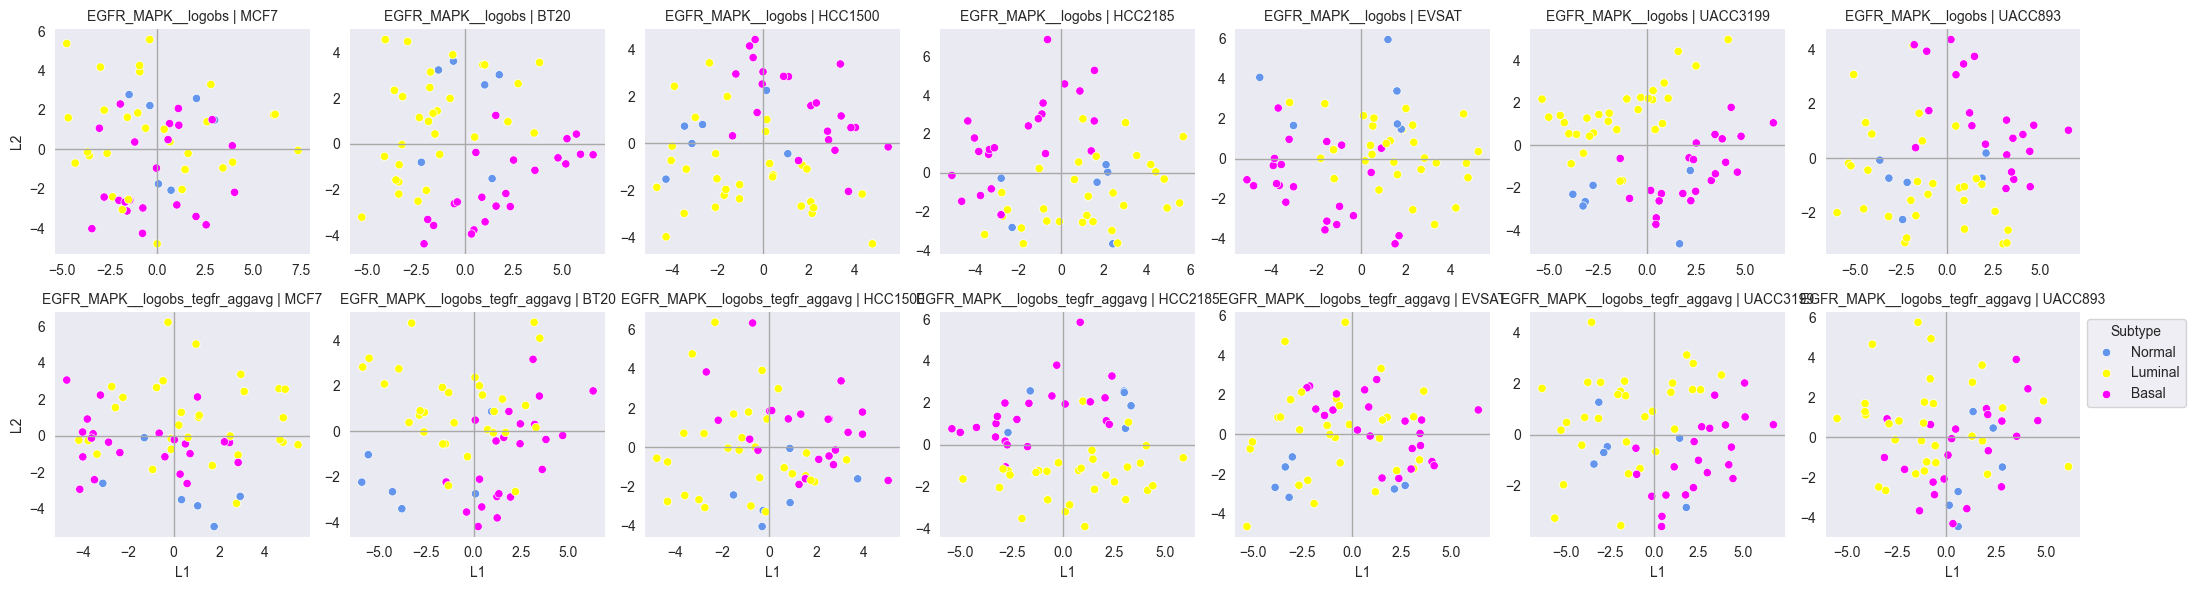

In [83]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.context == "cytof_init_plus_lb")],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "HCC2185", "EVSAT", "UACC3199", "UACC893"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Normal": "cornflowerblue",
        "Basal": "magenta"
    }
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="Subtype", bbox_to_anchor=(1, 1))

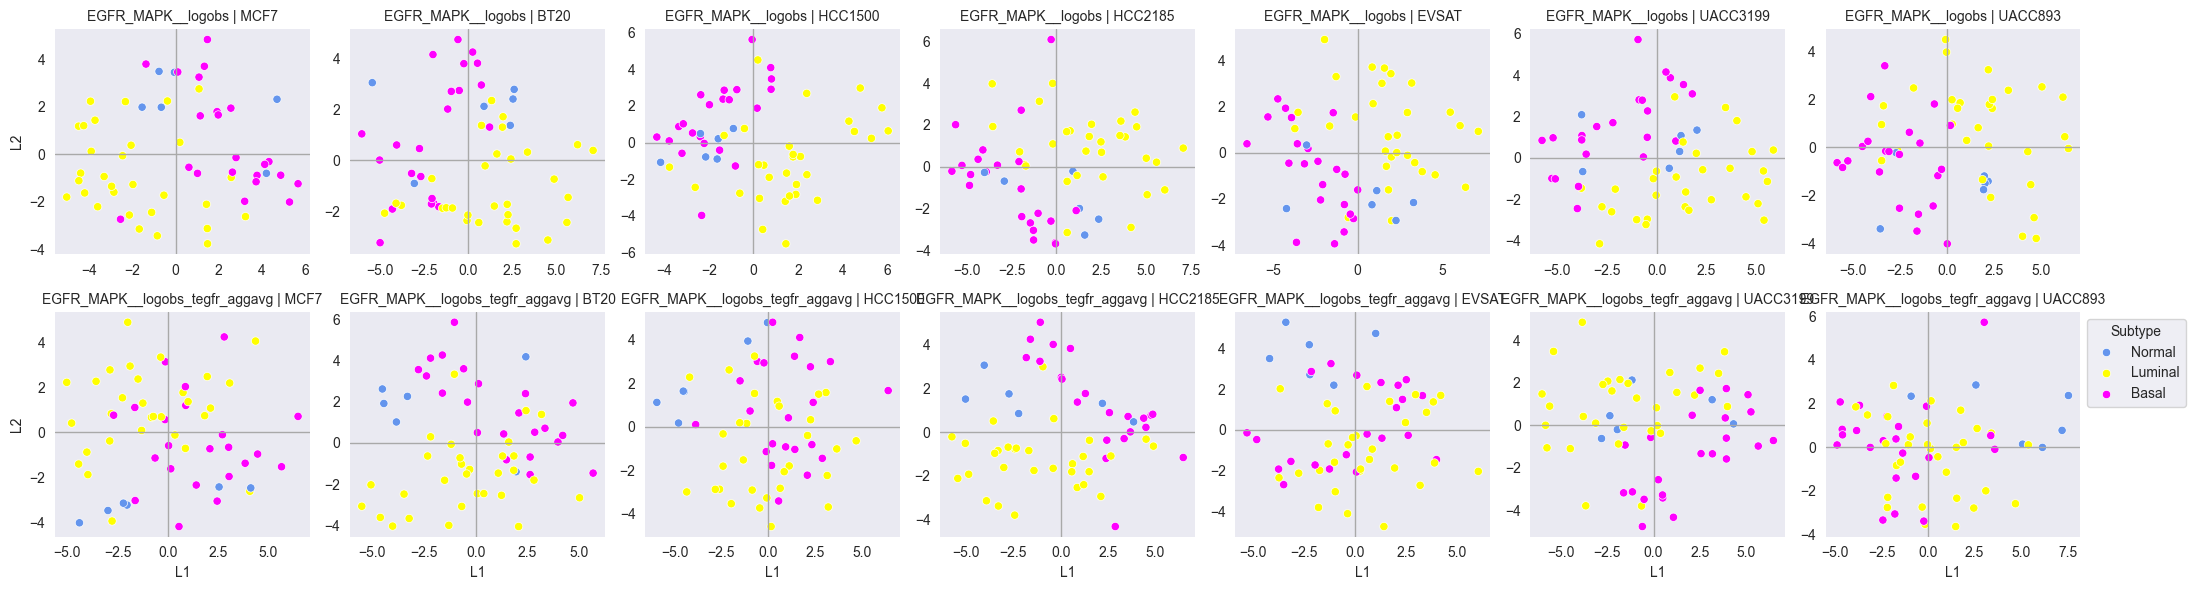

In [86]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.context == "multimodal")],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "HCC2185", "EVSAT", "UACC3199", "UACC893"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Normal": "cornflowerblue",
        "Basal": "magenta"
    }
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="Subtype", bbox_to_anchor=(1, 1))

In [ ]:
import petab

def _onehot_lb(samples: list[str]) -> pd.DataFrame:
    """
    Collapse intrinsic subtypes to Luminal/Basal buckets, then one-hot encode.
      LuminalA/LuminalB/HER2 → Luminal
      CL → Basal
    """
    df = load_marcotte_subtypes(samples).copy()
    lb = df["subtype_intrinsic"].astype(str)
    lb = lb.replace(["LuminalA", "LuminalB"], "Luminal")
    lb = lb.replace(["CL"], "Basal")
    lb = lb.replace(["HER2"], "Luminal")
    lb = lb.fillna("Unknown")
    X = pd.get_dummies(lb, prefix="lb", dtype=float)
    X = X.reindex(pd.Index([s for s in samples if s in X.index], name=petab.v1.PREEQUILIBRATION_CONDITION_ID))
    if len(X) == 1:
        for subtype in ["Luminal", "Basal", "Normal"]:
            if f"lb_{subtype}" not in X.columns:
                X[f"lb_{subtype}"] = 0.0
    # Ensure consistent one-hot-encoded feature ordering
    X = X[["lb_Basal", "lb_Luminal", "lb_Normal"]]
    return X


lb_onehot = _onehot_lb(pca_embedding_df.index.unique())
pca_embedding_df = pca_embedding_df.reset_index().merge(
    lb_onehot.reset_index(),
    left_on="cell_line",
    right_on="preequilibrationConditionId"
).set_index("cell_line")
pca_embedding_df

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.model == "EGFR_MAPK__logobs") & (pca_embedding_df.context == "cytof_init_plus_lb")],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="lb_Basal",
    palette="Blues",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="Subtype", bbox_to_anchor=(1, 1))
plt.savefig("basemodel_plusLBcontext_Basalonehotoverlay.pdf")

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (pca_embedding_df.context == "cytof_init_plus_lb")],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Normal": "cornflowerblue",
        "Basal": "magenta"
    }
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="Subtype", bbox_to_anchor=(1, 1))
plt.savefig("tegfrmodel_plusLBcontext_LBsubtypeoverlay.pdf")

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[(pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (pca_embedding_df.context == "cytof_init_plus_lb")],
    col="samples",
    col_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="time0 p.p90RSK", bbox_to_anchor=(1, 1))
plt.savefig("tEGFRmodel_plusLBcontext_p90RSKoverlay.pdf")

Pretty much no tEGFR relationship in the cytof_init_plus_lb embeddings

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

sub_df = pca_embedding_df[(pca_embedding_df.context == "cytof_init_plus_lb")]

for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    print("-----------------------------")
    for samples in sub_df.samples.unique():
        X = sub_df[(sub_df.model == model) & (sub_df.samples == samples)][["L1", "L2"]].values
        y = sub_df[(sub_df.model == model) & (sub_df.samples == samples)]["tEGFR"].values

        reg = LinearRegression().fit(X, y)
        direction = reg.coef_ / np.linalg.norm(reg.coef_)

        proj = X @ direction
        corr = np.corrcoef(proj, y)[0,1]
        print(f"Best linear projection correlation of embeddings with tEGFR for {model}, {samples}:", corr)

Comparison: lots of p.p90RSK structure

In [ ]:
for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    print("-----------------------------")
    for samples in sub_df.samples.unique():
        X = sub_df[(sub_df.model == model) & (sub_df.samples == samples)][["L1", "L2"]].values
        y = sub_df[(sub_df.model == model) & (sub_df.samples == samples)]["p.p90RSK"].values

        reg = LinearRegression().fit(X, y)
        direction = reg.coef_ / np.linalg.norm(reg.coef_)

        proj = X @ direction
        corr = np.corrcoef(proj, y)[0,1]
        print(f"Best linear projection correlation of embeddings with time0 p.p90RSK for {model}, {samples}:", corr)

In [ ]:
pca_embedding_df

In [ ]:
import itertools as itt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

def evaluate_embeddings_vs_tegfr(
    pca_embedding_df: pd.DataFrame,
    tegfr: pd.Series,
    binarize: bool = False,
    threshold: str | float = "mean"  # "mean" or a numeric threshold
) -> pd.DataFrame:
    """
    Evaluate how well embeddings (L1, L2) explain tegfr values.

    Parameters
    ----------
    pca_embedding_df : DataFrame with columns ["model","context","samples","L1","L2"]
    tegfr            : Series indexed by cell_line
    binarize         : If True, binarise tegfr into low/high before fitting
    threshold        : "median" or numeric value to split tegfr
    """

    r2_results = []

    for model, context, samples in itt.product(
        pca_embedding_df.model.unique(),
        pca_embedding_df.context.unique(),
        pca_embedding_df.samples.unique(),
    ):
        sub_df = pca_embedding_df[
            (pca_embedding_df.model == model) &
            (pca_embedding_df.samples == samples) &
            (pca_embedding_df.context == context)
        ]

        common_idx = sub_df.index.intersection(tegfr.index)
        if len(common_idx) < 3:
            continue

        X = sub_df.loc[common_idx, ["L1", "L2"]].values
        y = tegfr.loc[common_idx].values

        if binarize:
            # choose threshold
            if threshold == "mean":
                thr = np.mean(y)
            else:
                thr = float(threshold)
            y_bin = (y > thr).astype(int)

            # logistic regression for classification
            clf = LogisticRegression(max_iter=1000).fit(X, y_bin)
            y_pred = clf.predict(X)
            score = accuracy_score(y_bin, y_pred)
            metric = "accuracy"
        else:
            # linear regression for regression R²
            reg = LinearRegression().fit(X, y)
            score = reg.score(X, y)
            metric = "r2"

        r2_results.append({
            "model": model,
            "context": context,
            "samples": samples,
            "n_points": len(common_idx),
            metric: score
        })

    return pd.DataFrame(r2_results)

# continuous evaluation (R²)
r2_df = evaluate_embeddings_vs_tegfr(pca_embedding_df, tegfr, binarize=False)
print(r2_df.groupby(["model","context"]).r2.mean())

# binarised evaluation (classification accuracy)
acc_df = evaluate_embeddings_vs_tegfr(pca_embedding_df, tegfr, binarize=True, threshold="mean")
print(acc_df.groupby(["model","context"]).accuracy.mean())

No subtype divide in `tegfr_aggavg`, not even when subtype info is included in input context. Hence, no tEGFR correlation (R2 of linear fits decrease from base model)...How about p.p90RSK?

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="p.p90RSK", bbox_to_anchor=(1, 1))

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p38",
    palette="coolwarm",
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="p.p38", bbox_to_anchor=(1, 1))

Correlation/alignment with p.p90RSK and upstream p.p38 persists.

# Compute most aligned marker in each context/features/split

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

def top_markers_for_embedding(
    embedding_df: pd.DataFrame,
    tegfr: pd.Series,
    model: str,
    context: str,
    samples: str,
    features_df: pd.DataFrame,
    n_top: int = 1,
    use_tEGFR_axis: bool = False,
):
    """
    Find markers aligned with main and orthogonal directions of embedding.

    Parameters
    ----------
    embedding_df : DataFrame with ['L1','L2','context','samples',index=cell_line]
    tegfr        : Series indexed by cell_line
    context      : which context to filter
    samples      : which CV split
    features_df  : DataFrame with index = cell_line and marker columns
    n_top        : number of top markers to return
    use_tEGFR_axis : if True, define the primary axis by correlation with tEGFR,
                     otherwise use PC1 of embedding
    """
    sub_embed = embedding_df[
        (embedding_df["model"] == model) &
        (embedding_df["context"] == context) &
        (embedding_df["samples"] == samples)
    ][["L1","L2"]]

    common_idx = sub_embed.index.intersection(features_df.index).intersection(tegfr.index)
    if len(common_idx) < 3:
        return None

    X_embed = sub_embed.loc[common_idx].values
    feats = features_df.loc[common_idx].select_dtypes(include=[np.number])
    t = tegfr.loc[common_idx].values.reshape(-1,1)

    # --- define main / orthogonal axis ---
    if use_tEGFR_axis:
        reg = LinearRegression().fit(X_embed, t)
        main_axis = reg.coef_.ravel()
        main_axis /= np.linalg.norm(main_axis)
        orth_axis = np.array([-main_axis[1], main_axis[0]])  # 90° rotation
    else:
        pca = PCA(n_components=2).fit(X_embed)
        main_axis = pca.components_[0]
        orth_axis = pca.components_[1]

    # project embedding onto axes
    main_scores = X_embed @ main_axis
    orth_scores = X_embed @ orth_axis

    # correlations
    def corr_with_scores(scores):
        return feats.apply(lambda c: np.corrcoef(c.values, scores)[0,1])

    corr_main = corr_with_scores(main_scores).dropna()
    corr_orth = corr_with_scores(orth_scores).dropna()

    top_main = corr_main.abs().sort_values(ascending=False).head(n_top)
    top_orth = corr_orth.abs().sort_values(ascending=False).head(n_top)

    return {
        "model": model,
        "context": context,
        "samples": samples,
        "top_main": list(top_main.index),
        "corr_main": list(corr_main.loc[top_main.index]),
        "top_orth": list(top_orth.index),
        "corr_orth": list(corr_orth.loc[top_orth.index]),
    }

In [ ]:
import itertools as itt
import numpy as np
from common import FEATURES_OUTFILE
from training_configuration import CONTEXTS_FEATURES_3, SPLITS

results = []
feats = "RFE_10_permute"
for model, ctx, split in itt.product(PATHWAYS_3, pca_embedding_df.context.unique(), SPLITS):
    # load features_df as you do already
    features_df = pd.concat([
        pd.read_csv(FEATURES_OUTFILE.format(model=model, data=data,
                                            context=ctx, features=feats,
                                            dataset=ds, samples=split))
        for ds in ["train","val"]
    ]).set_index("preequilibrationConditionId")

    res = top_markers_for_embedding(
        embedding_df=pca_embedding_df,
        tegfr=tegfr,
        model=model,
        context=ctx,
        samples=split,
        features_df=features_df,
        n_top=3,
        use_tEGFR_axis=False  # flip False/True depending on analysis
    )
    if res:
        results.append(res)

pd.DataFrame(results)

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="p.p90RSK", bbox_to_anchor=(1, 1))
# plt.savefig("fig3_v2_embeddings_p90RSK_BT20.svg")
plt.show()

In [ ]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["BT20"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="Luminal/Basal", bbox_to_anchor=(1, 1))
# plt.savefig("fig3_v2_embeddings_LB_BT20.svg")
plt.show()

In [ ]:
import itertools as itt
from embedding_consistency import *

# Compute per (split vs other_split) comparisons for each validation cell
splits = ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]

summaries = []
for model, context in itt.product(PATHWAYS_3, pca_embedding_df.context.unique()):
    print(model, context)
    per_pair = compute_validation_neighborhood_consistency(
        {split: pca_embeddings_dict[model][(pca_embeddings_dict[model]["samples"] == split) & (pca_embeddings_dict[model].context == context)][["L1", "L2"]] for split in splits},
        {split: "c"+split for split in splits},
        n_neighbors=5,      # set N here
        metric="euclidean",  # or "cosine"
    )

    # Summaries per cell
    summary = summarize_consistency(per_pair)
    print(summary.jaccard_mean.mean())
    summaries.append(summary.assign(model=model, context=context))

    plot_distribution(per_pair)
    plot_per_cell_summary(summary)

overall_summary = pd.concat(summaries)

In [ ]:
overall_summary.groupby(["model", "context"]).agg({"jaccard_mean": "mean", "spearman_mean": "mean", "distance_corr_mean": "mean"})

In [ ]:
import matplotlib.pyplot as plt

agg_df = overall_summary.groupby(["model", "context"]).agg({
    "jaccard_mean": "mean",
    "spearman_mean": "mean",
    "distance_corr_mean": "mean"
}).reset_index()

melted = agg_df.melt(
    id_vars=["model", "context"],
    value_vars=["jaccard_mean", "spearman_mean", "distance_corr_mean"],
    var_name="metric", value_name="mean_value"
)

for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    sns.catplot(
        data=melted[melted.model == model],
        x="context",
        order=["cytof_init", "cytof_init_plus_lb", "cytof_init_plus_intr"],
        y="mean_value",
        hue="metric",
        col="model",
        kind="bar",
        palette="Set2",
        height=5,
        aspect=1.2
    )
    plt.ylabel("Mean metric")
    plt.xlabel("Context")
    plt.savefig(f"embedding_consistency_{model}_fig3.svg")

tEGFR model performs better, but embedding consistency is vastly degraded (as is the consistency of the parameter deviation blocks)...

## Parameters on embeddings

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools as itt
from sklearn.decomposition import PCA
from common import evaluations_dir
from training_configuration import PATHWAYS_3

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3
    ]
)

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset", "l1reg_inflater_output", "inflater_output_reg_epoch", "recon_loss", "inflater_bound", "n_epoch", "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

mean_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].mean().reset_index()

In [ ]:
def plot_parameters_on_embeddings(
        pca_embedding_df: pd.DataFrame,
        param_dev_df: pd.DataFrame,
        context: str,
        param_cols: list[str],
):
    mean_par_dev_df = param_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].mean().reset_index()
    context_par_dev_df = mean_par_dev_df[mean_par_dev_df.context == context]

    param_plot_df = pca_embedding_df[pca_embedding_df.context == context].reset_index().merge(
        context_par_dev_df,
        on=["cell_line", "context", "samples"]
    )


    for param in param_cols:
        # skip parameters with no variation at all
        if np.var(param_plot_df[param].values) == 0:
            continue
        g = sns.FacetGrid(
            param_plot_df,
            col="samples",
            col_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
            sharex=False,
            sharey=False
        )

        g.map_dataframe(
            sns.scatterplot,
            x="L1",
            y="L2",
            hue=param,
            palette="coolwarm",
        )

        plt.legend(title=param, bbox_to_anchor=(1, 1))

In [ ]:
plot_parameters_on_embeddings(
    pca_embedding_df[pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    par_dev_df[par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    "cytof_init",
    param_cols
)

## Checking HER3/HER4 levels

In [ ]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
ther3 = transcriptomics["ERBB3"]
ther3 -= ther3.mean()
ther4 = transcriptomics["ERBB4"]
ther4 -= ther4.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pher3 = proteomics["ERBB3"]
pher3 -= pher3.mean()
pher4 = proteomics["ERBB4"]
pher4 -= pher4.mean()
del proteomics

In [ ]:
marker_plot_df = pca_embedding_df[
    (pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg") & (pca_embedding_df.context == "cytof_init")
].copy()
marker_plot_df["tHER3"] = ther3.rename("tHER3").loc[marker_plot_df.index]
marker_plot_df["tHER4"] = ther4.rename("tHER4").loc[marker_plot_df.index]
marker_plot_df["pHER3"] = pher3.rename("pHER3").loc[marker_plot_df.index]
marker_plot_df["pHER4"] = pher4.rename("pHER4").loc[marker_plot_df.index]

In [ ]:
for marker in ["tHER3", "pHER3", "tHER4", "pHER4"]:
    g = sns.FacetGrid(
        marker_plot_df,
        col="samples",
        col_order=["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"],
        sharex=False,
        sharey=False
    )

    g.map_dataframe(
        sns.scatterplot,
        x="L1",
        y="L2",
        hue=marker,
        palette="coolwarm",
    )

    plt.legend(title=marker, bbox_to_anchor=(1, 1))
    plt.show()

